In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

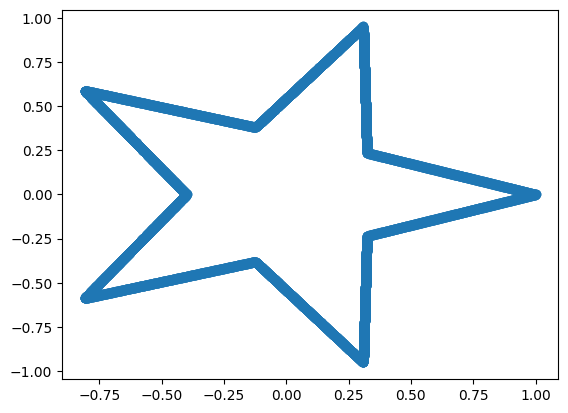

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [3]:
class Config:
    sigma_min = 0.01
    sigma_max = 4.0

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

In [4]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [5]:
def sigma_t(t, config):
    return config.sigma_min * (config.sigma_max / config.sigma_min) ** t

def g_t(t, config):
    sigma = sigma_t(t, config)
    c = math.sqrt(2.0 * math.log(config.sigma_max / config.sigma_min))

    return sigma * c

In [6]:
class VETrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            sigma = sigma_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = batch + sigma * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            loss = F.mse_loss(pred_z, z)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            if n % 100 == 0:
                print(f'Loss: {loss}')

In [7]:
config = Config()
trainer = VETrainer(config)

In [8]:
trainer.run()

Loss: 0.909378680229187
Loss: 0.647171881198883
Loss: 0.6364013520240783
Loss: 0.6252634804725647
Loss: 0.627193115901947
Loss: 0.6025128448486328
Loss: 0.6103372484207154
Loss: 0.5789954089164734
Loss: 0.5968680521965027
Loss: 0.578991084098816
Loss: 0.5799409480094909
Loss: 0.569793276309967
Loss: 0.5489221508026123
Loss: 0.5556840003967285
Loss: 0.5599360515594483
Loss: 0.5506752194404602
Loss: 0.5368421217918397
Loss: 0.5492470426559448
Loss: 0.5417243657112122
Loss: 0.5324141049861908


In [9]:
def sample(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device) * config.sigma_max

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            sigma = sigma_t(t_tensor, config)
            gt = g_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / sigma

            drift = (gt ** 2) * score * dt
            diffusion = gt * torch.randn_like(x) * math.sqrt(dt)

            x = x + drift + diffusion

        return x.cpu().numpy()

In [10]:
samples = sample(trainer.model, trainer.config, 1000)

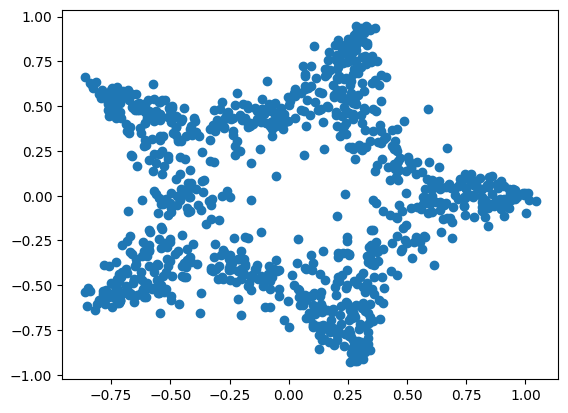

In [11]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

# Реализация VP-SDE

In [23]:
class VPConfig:
    lr = 1e-3
    epochs = 800
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

    beta_min = 0.1
    beta_max = 20.0

    schedule = 'linear'
    loss_weight = 'uniform'
    cosine_s = 0.008

In [24]:
def vp_alpha_bar(t, config):
    if config.schedule == 'linear':
        integral = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t ** 2
        return torch.exp(-integral)
    if config.schedule == 'cosine':
        s = config.cosine_s
        t = torch.clamp(t, 0.0, 0.9999)
        c0 = math.cos(s / (1 + s) * math.pi / 2) ** 2
        phi = (t + s) / (1 + s) * math.pi / 2
        return torch.cos(phi) ** 2 / c0
    raise ValueError(f'Unknown schedule: {config.schedule}')

def vp_beta_t(t, config):
    if config.schedule == 'linear':
        return config.beta_min + (config.beta_max - config.beta_min) * t
    if config.schedule == 'cosine':
        s = config.cosine_s
        t = torch.clamp(t, 0.0, 0.999)
        phi = (t + s) / (1 + s) * math.pi / 2
        beta = math.pi * torch.tan(phi) / (1 + s)
        return torch.clamp(beta, max=50.0)
    raise ValueError(f'Unknown schedule: {config.schedule}')

def vp_mean_std(t, config):
    alpha_bar = torch.clamp(vp_alpha_bar(t, config), 1e-6, 1.0)
    mean_coeff = torch.sqrt(alpha_bar)
    std = torch.sqrt(torch.clamp(1 - alpha_bar, 1e-6, 1.0))
    return mean_coeff, std

def vp_loss_weight(t, config):
    alpha_bar = torch.clamp(vp_alpha_bar(t, config), 1e-6, 1 - 1e-6)
    snr = alpha_bar / (1 - alpha_bar)

    if config.loss_weight == 'uniform':
        return torch.ones_like(t)
    if config.loss_weight == 'snr':
        return snr
    if config.loss_weight == 'inv_snr':
        return 1 / snr
    if config.loss_weight == 'sqrt_snr':
        return torch.sqrt(snr)
    if config.loss_weight == 'variance':
        return 1 - alpha_bar
    raise ValueError(f'Unknown loss weight: {config.loss_weight}')

In [25]:
class VPScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU()
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.net(x_input)

In [26]:
class VPTrainer:
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = VPScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

        self.loss_history = []

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            mean_coeff, std = vp_mean_std(t, self.config)

            eps = torch.randn_like(batch)
            x_t = mean_coeff * batch + std * eps

            eps_pred = self.model(x_t, t)
            per_sample = ((eps_pred - eps) ** 2).sum(dim=1, keepdim=True)
            weights = vp_loss_weight(t, self.config)
            loss = (weights * per_sample).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        avg_loss = total_loss / len(self.data)
        self.loss_history.append(avg_loss)
        return avg_loss

    def run(self, verbose_step=100):
        for epoch in range(self.config.epochs):
            loss = self.train_epoch()
            if epoch % verbose_step == 0 or epoch == self.config.epochs - 1:
                print(
                    f"schedule={self.config.schedule}, "
                    f"weight={self.config.loss_weight}, "
                    f"epoch={epoch}, loss={loss:.6f}"
                )

In [27]:
def vp_sample(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps, 0, -1):
            t_value = i / config.num_timesteps
            t = torch.full((num_samples, 1), t_value, device=device)

            beta = vp_beta_t(t, config)
            _, std = vp_mean_std(t, config)

            eps_pred = model(x, t)
            score = -eps_pred / std

            drift = -0.5 * beta * x - beta * score
            diffusion = torch.sqrt(beta)

            z = torch.randn_like(x) if i > 1 else torch.zeros_like(x)
            x = x - drift * dt + diffusion * math.sqrt(dt) * z

        return x.cpu().numpy()


### Базовый запуск VP-SDE

In [28]:
vp_config = VPConfig()
vp_trainer = VPTrainer(vp_config)

In [29]:
vp_trainer.run()

schedule=linear, weight=uniform, epoch=0, loss=1.653655
schedule=linear, weight=uniform, epoch=100, loss=0.362726
schedule=linear, weight=uniform, epoch=200, loss=0.332520
schedule=linear, weight=uniform, epoch=300, loss=0.304023
schedule=linear, weight=uniform, epoch=400, loss=0.314058
schedule=linear, weight=uniform, epoch=500, loss=0.314880
schedule=linear, weight=uniform, epoch=600, loss=0.310441
schedule=linear, weight=uniform, epoch=700, loss=0.304270
schedule=linear, weight=uniform, epoch=799, loss=0.310146


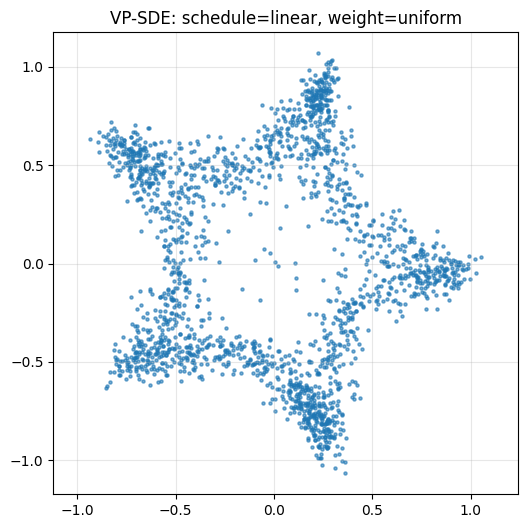

In [30]:
vp_samples = vp_sample(vp_trainer.model, vp_trainer.config, 2000)
plt.figure(figsize=(6, 6))
plt.scatter(vp_samples[:, 0], vp_samples[:, 1], s=5, alpha=0.6)
plt.title(f"VP-SDE: schedule={vp_config.schedule}, weight={vp_config.loss_weight}")
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

### Сравнение расписаний и вариантов перезвешивания лосса

Запускается набор экспериментов:
- расписания: `linear`, `cosine`
- веса лосса: `uniform`, `snr`, `inv_snr`, `variance`

После обучения строятся:
- графики обучения
- облака сэмплов
- сводная таблица по финальному лоссу


In [31]:
def clone_config(schedule, loss_weight, epochs=600):
    cfg = VPConfig()
    cfg.schedule = schedule
    cfg.loss_weight = loss_weight
    cfg.epochs = epochs
    return cfg

def run_experiment(schedule, loss_weight, epochs=600):
    cfg = clone_config(schedule, loss_weight, epochs=epochs)
    trainer = VPTrainer(cfg)
    trainer.run(verbose_step=max(epochs // 6, 1))
    samples = vp_sample(trainer.model, cfg, 2000)
    return {
        'config': cfg,
        'trainer': trainer,
        'samples': samples,
        'final_loss': trainer.loss_history[-1]
    }

In [32]:
experiment_grid = [
    ('linear', 'uniform'),
    ('linear', 'snr'),
    ('linear', 'inv_snr'),
    ('linear', 'variance'),
    ('cosine', 'uniform'),
    ('cosine', 'snr'),
    ('cosine', 'inv_snr'),
    ('cosine', 'variance'),
]

results = {}
for schedule, loss_weight in experiment_grid:
    key = f'{schedule}_{loss_weight}'
    results[key] = run_experiment(schedule, loss_weight, epochs=500)

schedule=linear, weight=uniform, epoch=0, loss=1.611481
schedule=linear, weight=uniform, epoch=83, loss=0.353599
schedule=linear, weight=uniform, epoch=166, loss=0.335888
schedule=linear, weight=uniform, epoch=249, loss=0.335721
schedule=linear, weight=uniform, epoch=332, loss=0.320873
schedule=linear, weight=uniform, epoch=415, loss=0.314768
schedule=linear, weight=uniform, epoch=498, loss=0.310765
schedule=linear, weight=uniform, epoch=499, loss=0.321297
schedule=linear, weight=snr, epoch=0, loss=147.465524
schedule=linear, weight=snr, epoch=83, loss=73.864130
schedule=linear, weight=snr, epoch=166, loss=83.375414
schedule=linear, weight=snr, epoch=249, loss=66.571012
schedule=linear, weight=snr, epoch=332, loss=566.730379
schedule=linear, weight=snr, epoch=415, loss=309.779421
schedule=linear, weight=snr, epoch=498, loss=364.453622
schedule=linear, weight=snr, epoch=499, loss=158.640103
schedule=linear, weight=inv_snr, epoch=0, loss=2156.491709
schedule=linear, weight=inv_snr, epoch

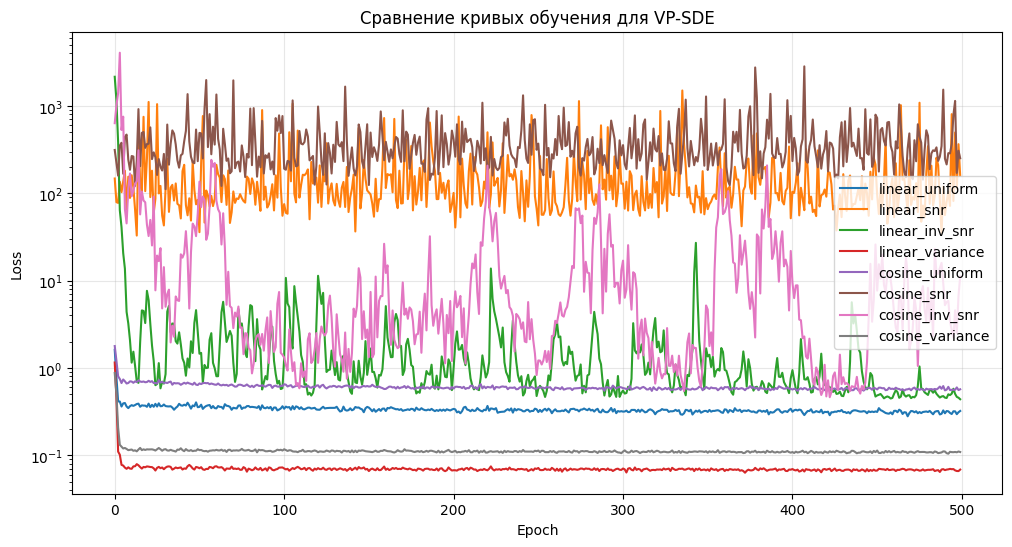

In [33]:
plt.figure(figsize=(12, 6))
for key, result in results.items():
    plt.plot(result['trainer'].loss_history, label=key)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Сравнение кривых обучения для VP-SDE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

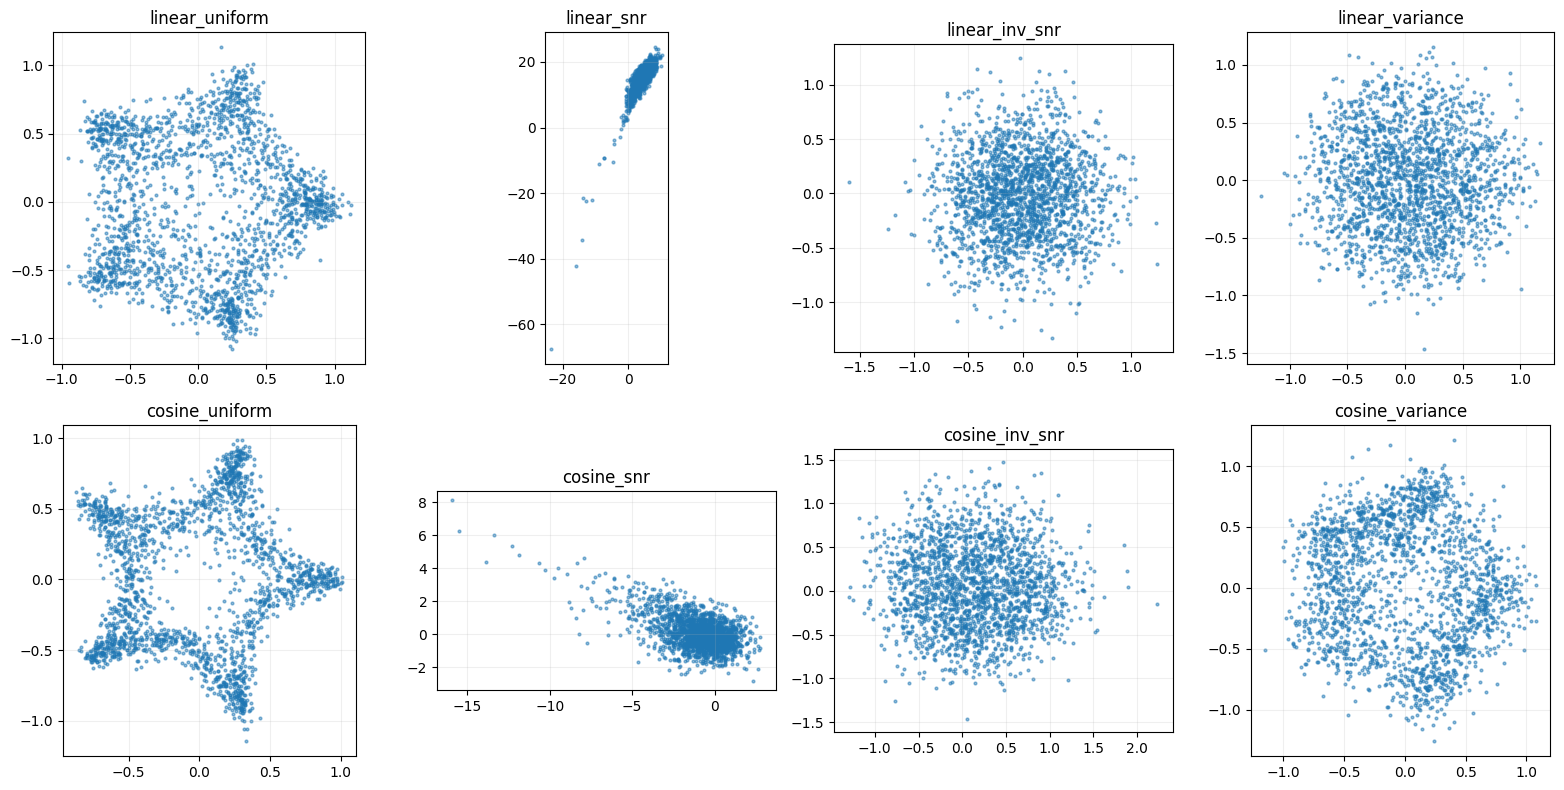

In [34]:
rows = len(set(k.split('_')[0] for k in results.keys()))
cols = 4

fig, axes = plt.subplots(rows, cols, figsize=(16, 8))
axes = np.array(axes).reshape(rows, cols)

ordered_keys = [
    'linear_uniform',
    'linear_snr',
    'linear_inv_snr',
    'linear_variance',
    'cosine_uniform',
    'cosine_snr',
    'cosine_inv_snr',
    'cosine_variance',
]

for ax, key in zip(axes.flat, ordered_keys):
    s = results[key]['samples']
    ax.scatter(s[:, 0], s[:, 1], s=4, alpha=0.5)
    ax.set_title(key)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [35]:
summary = []
for key, result in results.items():
    summary.append((key, result['final_loss']))

summary = sorted(summary, key=lambda x: x[1])
for key, loss in summary:
    print(f'{key:20s}  final_loss={loss:.6f}')

linear_variance       final_loss=0.068485
cosine_variance       final_loss=0.108886
linear_uniform        final_loss=0.321297
linear_inv_snr        final_loss=0.437782
cosine_uniform        final_loss=0.568872
cosine_inv_snr        final_loss=11.202686
linear_snr            final_loss=158.640103
cosine_snr            final_loss=251.602212


## Выводы

Получаем такие выводы после запуска экспериментов:

1. VP-SDE работает, если при генерации получается облако точек в форме звезды.
2. Перезвешивание лосса по времени влияет на качество:
   - `snr` обычно сильнее фокусируется на малошумных шагах
   - `inv_snr` сильнее поднимает вклад больших времен, где шум высокий
   - `variance` даёт более мягкий компромисс
   - `uniform` является базовой нейтральной точкой отсчёта
3. Сравнение линейного и косинусного расписаний:
   - косинусное расписание часто даёт более плавное распределение шума по времени
   - линейное проще и стабильнее как базовый вариант
   - итоговый выбор делается по качеству формы звезды и стабильности лосса на графиках
